In [21]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


file_path = r"C:/Users/Dalbir/Downloads/Trends-Forecasting-Analytics-MLOps-Vertex-AI/data/processed_file/sales_featured.parquet"
df = pd.read_parquet(file_path)

monthly_sales = df.groupby(pd.Grouper(key='order_date', freq='ME'))['sales'].sum().reset_index()
monthly_sales = monthly_sales.set_index('order_date')
y = monthly_sales['sales']

In [22]:
model = ARIMA(y, order=(3,1,1))
results = model.fit()
forecast = results.get_forecast(steps=6)
forecast_df = forecast.summary_frame()
monthly_sales['arima_forecast'] = results.predict(start=1, end=len(y), dynamic=False)

c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as startin

In [23]:
forecast_df

sales,mean,mean_se,mean_ci_lower,mean_ci_upper
2020-02-29,2.151687e+06,9.189519e+05,3.505746e+05,3.952800e+06
2020-03-31,3.454870e+05,9.392001e+05,-1.495311e+06,2.186285e+06
2020-04-30,3.851271e+06,9.911363e+05,1.908679e+06,5.793862e+06
2020-05-31,2.411229e+06,1.095611e+06,2.638707e+05,4.558587e+06
2020-06-30,4.332370e+06,1.096032e+06,2.184187e+06,6.480553e+06
2020-07-31,1.787484e+06,1.131553e+06,-4.303184e+05,4.005287e+06


In [24]:
monthly_sales

,sales,arima_forecast
order_date,,
2019-01-31,1812742.87,NaN
2019-02-28,2200078.08,6.047810e+05
2019-03-31,2804973.35,2.586874e+06
2019-04-30,3389217.98,1.615796e+06
2019-05-31,3150616.23,2.221955e+06
2019-06-30,2576280.15,2.150818e+06
2019-07-31,2646461.32,1.685448e+06
2019-08-31,2241083.37,1.890928e+06
2019-09-30,2094465.69,2.305911e+06


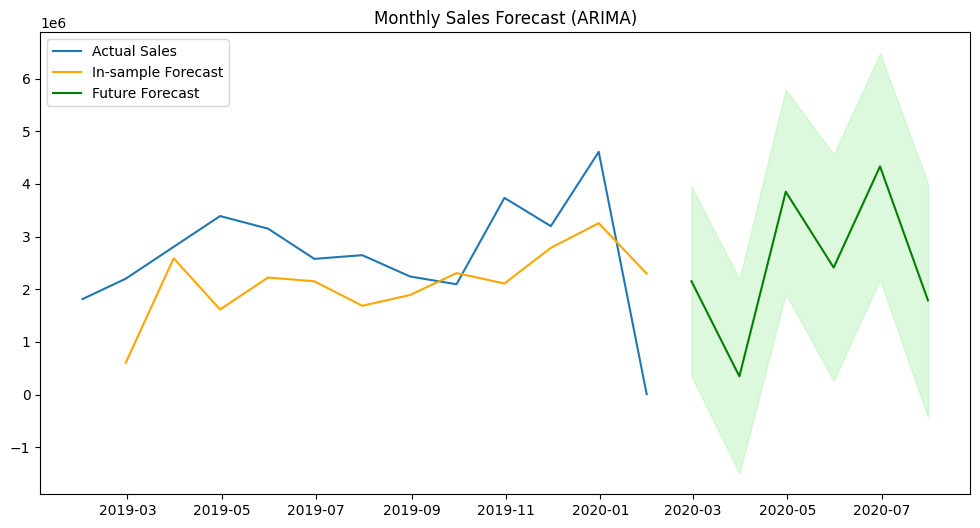

In [25]:
plt.figure(figsize=(12,6))
plt.plot(y, label="Actual Sales")
plt.plot(monthly_sales['arima_forecast'], label="In-sample Forecast", color="orange")
plt.plot(forecast_df.index, forecast_df['mean'], label="Future Forecast", color="green")
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color="lightgreen", alpha=0.3)
plt.title("Monthly Sales Forecast (ARIMA)")
plt.legend()
plt.show()

In [27]:
prophet_df = monthly_sales.reset_index()[['order_date', 'sales']].rename(columns={'order_date': 'ds', 'sales': 'y'})
prophet_df

,ds,y
0,2019-01-31,1812742.87
1,2019-02-28,2200078.08
2,2019-03-31,2804973.35
3,2019-04-30,3389217.98
4,2019-05-31,3150616.23
5,2019-06-30,2576280.15
6,2019-07-31,2646461.32
7,2019-08-31,2241083.37
8,2019-09-30,2094465.69
9,2019-10-31,3734777.86


In [8]:
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(prophet_df)
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

12:27:31 - cmdstanpy - INFO - Chain [1] start processing
12:27:32 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\Dalbir\Downloads\Trends-Forecasting-Analytics-MLOps-Vertex-AI\venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [9]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

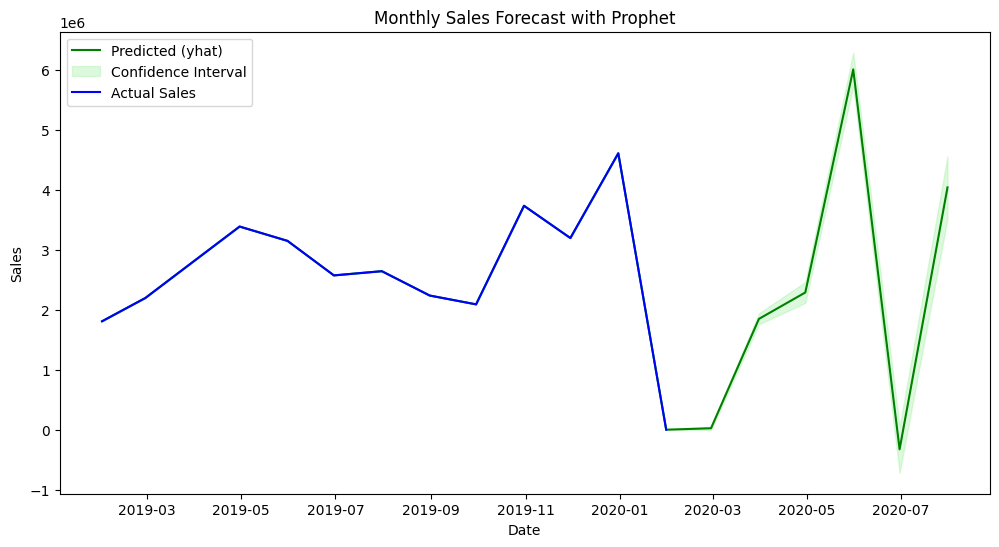

In [10]:
plt.figure(figsize=(12,6))
plt.plot(forecast['ds'], forecast['yhat'], color='green', label='Predicted (yhat)')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                 color='lightgreen', alpha=0.3, label='Confidence Interval')
plt.plot(prophet_df['ds'], prophet_df['y'], color='blue', label='Actual Sales')
plt.title('Monthly Sales Forecast with Prophet')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()
